In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from empyrical import max_drawdown
from calendar import monthrange
import warnings


warnings.filterwarnings("ignore")
#Annual rebalancing
def yearly_returns(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True) 
    returns = {}
    for year in range(20006, 2026): 
        start_date = f"{year-1}-12-31"
        end_date = f"{year}-12-31"
        start_price = df['Adj Close'].loc[:start_date].iloc[-1]
        end_price = df['Adj Close'].loc[:end_date].iloc[-1]
        yearly_return = (end_price - start_price) / start_price
        returns[year] = yearly_return
    return pd.Series(returns)

tickers = ['ews', 'ewj', 'inda', 'mchi', 'ewt', 'ewz', 'ewy', 'ewc', 'ewu', 'ewg', 'eww', 'ewa', 'ewl', 'ewp', 'argt']

data = {ticker.lower(): pd.read_csv(f"{ticker}_weekly_return_detailed.csv") for ticker in tickers}

yearly_returns_dict = {key: yearly_returns(df) for key, df in data.items()}
final_df = pd.DataFrame(yearly_returns_dict)
final_df.index.name = 'Date'

cash_w = 100
cash_m = 100
cash_l = 100

cash_annual_w = []
cash_annual_m = []
cash_annual_l = []

for year in range(2014, 2025):
    sorted_returns = final_df.loc[year].sort_values()
    first_three = sorted_returns.iloc[0:5]
    middle_three = sorted_returns.iloc[5:10]
    last_three = sorted_returns.iloc[10:15]
    next_year = year + 1
    if next_year in final_df.index:
        returns_next_year_w = final_df.loc[next_year][last_three.index]
        total_return_w = ((cash_w / 5) * (1 + returns_next_year_w)).sum()
        cash_w = total_return_w
        cash_annual_w.append((year + 1, cash_w))
        returns_next_year_m = final_df.loc[next_year][middle_three.index]
        total_return_m = ((cash_m / 5) * (1 + returns_next_year_m)).sum()
        cash_m = total_return_m
        cash_annual_m.append((year + 1, cash_m))
        returns_next_year_l = final_df.loc[next_year][first_three.index]
        total_return_l = ((cash_l / 5) * (1 + returns_next_year_l)).sum()
        cash_l = total_return_l
        cash_annual_l.append((year + 1, cash_l))

years_w, cash_values_w = zip(*cash_annual_w)
years_m, cash_values_m = zip(*cash_annual_m)
years_l, cash_values_l = zip(*cash_annual_l)

years = range(2015, 2026)
df1 = pd.DataFrame({'Year': years, 'Winners': cash_values_w})
df1["Median"]=cash_values_m
df1["Losers"]=cash_values_l

initial_value = 100
df1['Annualized_Return_Winners'] = (df1['Winners'] - df1['Winners'].shift(1, fill_value=initial_value)) / df1['Winners'].shift(1, fill_value=initial_value)*100
df1['Annualized_Return_Median'] = (df1['Median'] - df1['Median'].shift(1, fill_value=initial_value)) / df1['Median'].shift(1, fill_value=initial_value)*100
df1['Annualized_Return_Losers'] = (df1['Losers'] - df1['Losers'].shift(1, fill_value=initial_value)) / df1['Losers'].shift(1, fill_value=initial_value)*100

# daily returns dataframe
daily_returns_df = pd.DataFrame()

for etf, df in data.items():
    df = df.reset_index() 
    df['Date'] = pd.to_datetime(df['Date'])
    df.rename(columns={'Return': etf}, inplace=True)
    if daily_returns_df.empty:
        daily_returns_df = df[['Date', etf]]
    else:
        daily_returns_df = pd.merge(daily_returns_df, df[['Date', etf]], on='Date', how='outer')

daily_returns_df.set_index('Date', inplace=True)

# dataframes for bottom, middle, and top ETFs
result_dfs = {
    'bottom': pd.DataFrame(),
    'middle': pd.DataFrame(),
    'top': pd.DataFrame()
}

for date in range(2014, 2026):
    x = final_df.loc[date].sort_values()
    
    for i, group in enumerate(['bottom', 'middle', 'top']):
        selected = x.iloc[i*5:(i+1)*5]
        temp_df = pd.DataFrame({
            0: [selected.index[0]],
            1: [selected.index[1]],
            2: [selected.index[2]],
            3: [selected.index[3]],
            4: [selected.index[4]]
        }, index=[date])
        
        result_dfs[group] = pd.concat([result_dfs[group], temp_df])
# average daily returns for each group
final_result_dfs = {
    'bottom': pd.DataFrame(),
    'middle': pd.DataFrame(),
    'top': pd.DataFrame()
}

for year in range(2014, 2026):
    for group in ['bottom', 'middle', 'top']:
        etfs = result_dfs[group].loc[year].values
        selected_returns = daily_returns_df[etfs]
        selected_returns_year = selected_returns[selected_returns.index.year == year+1]
        avg_daily_returns = selected_returns_year.mean(axis=1)
        final_result_dfs[group] = pd.concat([final_result_dfs[group], avg_daily_returns])
df1.set_index("Year", inplace=True)
for group in ['top', 'middle', 'bottom']:
    yearly_volatility = final_result_dfs[group].groupby(final_result_dfs[group].index.year).std() * np.sqrt(252)
    df1[group]=yearly_volatility[0]
df1.rename(columns={"bottom": "Volatility_Losers",
            "middle": "Volatility_Median",
            "top": "Volatility_Winners"}, inplace=True)
df1["Sharpe_Ratio_Winners"]=df1["Annualized_Return_Winners"]/df1["Volatility_Winners"]
df1["Sharpe_Ratio_Median"]=df1["Annualized_Return_Median"]/df1["Volatility_Median"]
df1["Sharpe_Ratio_Losers"]=df1["Annualized_Return_Losers"]/df1["Volatility_Losers"]
for group in ['bottom', 'middle', 'top']:
    final_result_dfs[group] = final_result_dfs[group] / 100
for group in ['top', 'middle', 'bottom']:
    mdd=final_result_dfs[group].groupby(final_result_dfs[group].index.year).apply(lambda x: max_drawdown(x))
    df1[group] = mdd*100
df1.rename(columns={"bottom": "MDD_Losers",
            "middle": "MDD_Median",
            "top": "MDD_Winners"}, inplace=True)
# max drawdown for each group
max_drawdowns = {}
for group in ['bottom', 'middle', 'top']:
    max_drawdowns[group] = max_drawdown(final_result_dfs[group])

# Extract only the values from the max_drawdowns dictionary and round to two decimal places
max_drawdowns_values_a = {group: value.iloc[0] for group, value in max_drawdowns.items()}

w_a_maxdd=max_drawdowns_values_a["top"]
m_a_maxdd=max_drawdowns_values_a["middle"]
l_a_maxdd=max_drawdowns_values_a["bottom"]

df2=pd.DataFrame()
df2=df1
df2.head(11)
df1.to_csv("annual_all.csv")

In [2]:
final_result_dfs["bottom"].to_csv("Annual_losers.csv")
final_result_dfs["middle"].to_csv("Annual_median.csv")
final_result_dfs["top"].to_csv("Annual_winners.csv")

In [3]:
#Semi-Annual Rebalancing
import pandas as pd
import matplotlib.pyplot as plt

#returns calculation
def semi_annual_returns(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True) 
    returns = {}
    for year in range(2014, 2026):
        start_date_1 = f"{year-1}-12-31"
        end_date_1 = f"{year}-06-30"
        start_price_1 = df['Adj Close'].loc[:start_date_1].iloc[-1]
        end_price_1 = df['Adj Close'].loc[:end_date_1].iloc[-1]
        half_year_return_1 = (end_price_1 - start_price_1) / start_price_1
        returns[f"{year}-01"] = half_year_return_1
        
        start_date_2 = f"{year}-06-30"
        end_date_2 = f"{year}-12-31"
        start_price_2 = df['Adj Close'].loc[:start_date_2].iloc[-1]
        end_price_2 = df['Adj Close'].loc[:end_date_2].iloc[-1]
        half_year_return_2 = (end_price_2 - start_price_2) / start_price_2
        returns[f"{year}-02"] = half_year_return_2
    
    return pd.Series(returns)

tickers = ['ews', 'ewj', 'inda', 'mchi', 'ewt', 'ewz', 'ewy', 'ewc', 'ewu', 'ewg', 'eww', 'ewa', 'ewl', 'ewp', 'argt']
data = {ticker.lower(): pd.read_csv(f"{ticker}_weekly_return_detailed.csv") for ticker in tickers}

semi_annual_returns_dict = {key: semi_annual_returns(df) for key, df in data.items()}
final_df = pd.DataFrame(semi_annual_returns_dict)
final_df.index.name = 'Date'

cash_w = 100
cash_m = 100
cash_l = 100

cash_semi_annual_w = []
cash_semi_annual_m = []
cash_semi_annual_l = []

#cash calculation
for period in final_df.index[1:-1]:
    sorted_returns = final_df.loc[period].sort_values()
    first_three = sorted_returns.iloc[0:5]
    middle_three = sorted_returns.iloc[5:10]
    last_three = sorted_returns.iloc[10:15]
    next_period = final_df.index[final_df.index.get_loc(period) + 1]
    
    returns_next_period_w = final_df.loc[next_period][last_three.index]
    total_return_w = ((cash_w / 5) * (1 + returns_next_period_w)).sum()
    cash_w = total_return_w
    cash_semi_annual_w.append((next_period, cash_w))
    
    returns_next_period_m = final_df.loc[next_period][middle_three.index]
    total_return_m = ((cash_m / 5) * (1 + returns_next_period_m)).sum()
    cash_m = total_return_m
    cash_semi_annual_m.append((next_period, cash_m))
    
    returns_next_period_l = final_df.loc[next_period][first_three.index]
    total_return_l = ((cash_l / 5) * (1 + returns_next_period_l)).sum()
    cash_l = total_return_l
    cash_semi_annual_l.append((next_period, cash_l))

periods_w, cash_values_w = zip(*cash_semi_annual_w)
periods_m, cash_values_m = zip(*cash_semi_annual_m)
periods_l, cash_values_l = zip(*cash_semi_annual_l)
cash_values_w=cash_values_w[1::2]
cash_values_m=cash_values_m[1::2]
cash_values_l=cash_values_l[1::2]
years = range(2015, 2026)
df1 = pd.DataFrame({'Year': years, 'Winners': cash_values_w})
df1["Median"]=cash_values_m
df1["Losers"]=cash_values_l

initial_value = 100
df1['Annualized_Return_Winners'] = (df1['Winners'] - df1['Winners'].shift(1, fill_value=initial_value)) / df1['Winners'].shift(1, fill_value=initial_value)*100
df1['Annualized_Return_Median'] = (df1['Median'] - df1['Median'].shift(1, fill_value=initial_value)) / df1['Median'].shift(1, fill_value=initial_value)*100
df1['Annualized_Return_Losers'] = (df1['Losers'] - df1['Losers'].shift(1, fill_value=initial_value)) / df1['Losers'].shift(1, fill_value=initial_value)*100
# daily returns dataframe
daily_returns_df = pd.DataFrame()

for etf, df in data.items():
    df = df.reset_index() 
    df['Date'] = pd.to_datetime(df['Date'])
    df.rename(columns={'Return': etf}, inplace=True)
    if daily_returns_df.empty:
        daily_returns_df = df[['Date', etf]]
    else:
        daily_returns_df = pd.merge(daily_returns_df, df[['Date', etf]], on='Date', how='outer')

daily_returns_df.set_index('Date', inplace=True)

# dataframes for bottom, middle, and top ETFs
result_dfs = {
    'bottom': pd.DataFrame(),
    'middle': pd.DataFrame(),
    'top': pd.DataFrame()
}

for date in final_df.index[1:]:
    x = final_df.loc[date].sort_values()
    
    for i, group in enumerate(['bottom', 'middle', 'top']):
        selected = x.iloc[i*5:(i+1)*5]
        temp_df = pd.DataFrame({
            0: [selected.index[0]],
            1: [selected.index[1]],
            2: [selected.index[2]],
            3: [selected.index[3]],
            4: [selected.index[4]]
        }, index=[date])
        
        result_dfs[group] = pd.concat([result_dfs[group], temp_df])


# average daily returns for each group
final_result_dfs = {
    'bottom': pd.DataFrame(),
    'middle': pd.DataFrame(),
    'top': pd.DataFrame()
}

for date in final_df.index[1:]:
    year, half = int(date[:4]), int(date[-1])
    
    if half == 1:
        current_date = pd.Timestamp(year=year, month=1, day=1)
        next_half_start = pd.Timestamp(year=year, month=7, day=1)
        next_half_end = pd.Timestamp(year=year, month=12, day=31)
    else:
        current_date = pd.Timestamp(year=year, month=7, day=1)
        next_half_start = pd.Timestamp(year=year+1, month=1, day=1)
        next_half_end = pd.Timestamp(year=year+1, month=6, day=30)
    
    for group in ['bottom', 'middle', 'top']:
        etfs = result_dfs[group].loc[date].values
        selected_returns = daily_returns_df[etfs]
        
        # Ensure that the end date does not exceed the dataset's available date range
        next_half_end = min(next_half_end, daily_returns_df.index[-1])
        
        # Select returns for the calculated period
        selected_returns_period = selected_returns.loc[next_half_start:next_half_end]
        avg_daily_returns = selected_returns_period.mean(axis=1)
        
        # average daily returns concatenation
        final_result_dfs[group] = pd.concat([final_result_dfs[group], avg_daily_returns])
df1.set_index("Year", inplace=True)
for group in ['top', 'middle', 'bottom']:
    yearly_volatility = final_result_dfs[group].groupby(final_result_dfs[group].index.year).std() * np.sqrt(252)
    df1[group]=yearly_volatility[0]
df1.rename(columns={"bottom": "Volatility_Losers",
            "middle": "Volatility_Median",
            "top": "Volatility_Winners"}, inplace=True)
df1["Sharpe_Ratio_Winners"]=df1["Annualized_Return_Winners"]/df1["Volatility_Winners"]
df1["Sharpe_Ratio_Median"]=df1["Annualized_Return_Median"]/df1["Volatility_Median"]
df1["Sharpe_Ratio_Losers"]=df1["Annualized_Return_Losers"]/df1["Volatility_Losers"]
for group in ['bottom', 'middle', 'top']:
    final_result_dfs[group] = final_result_dfs[group] / 100
for group in ['top', 'middle', 'bottom']:
    mdd=final_result_dfs[group].groupby(final_result_dfs[group].index.year).apply(lambda x: max_drawdown(x))
    df1[group] = mdd*100
df1.rename(columns={"bottom": "MDD_Losers",
            "middle": "MDD_Median",
            "top": "MDD_Winners"}, inplace=True)
# max drawdown for each group
max_drawdowns = {}
for group in ['bottom', 'middle', 'top']:
    max_drawdowns[group] = max_drawdown(final_result_dfs[group])

# Extract only the values from the max_drawdowns dictionary and round to two decimal places
#max_drawdowns_values_sa = {group: round(float(value), 2) if isinstance(value, (float, np.float64)) else round(float(value.iloc[0]), 2) for group, value in max_drawdowns.items()}
max_drawdowns_values_sa = {group: value if isinstance(value, (float, np.float64)) else float(value.iloc[0]) for group, value in max_drawdowns.items()}
w_sa_maxdd = max_drawdowns_values_sa["top"]
m_sa_maxdd = max_drawdowns_values_sa["middle"]
l_sa_maxdd = max_drawdowns_values_sa["bottom"]

df3=pd.DataFrame()
df3=df1
df3.tail(5)
df1.to_csv("semiannual_all.csv")

In [4]:
final_result_dfs["bottom"].to_csv("Semi_Annual_losers.csv")
final_result_dfs["middle"].to_csv("Semi_Annual_median.csv")
final_result_dfs["top"].to_csv("Semi_Annual_winners.csv")

In [5]:
# Quarterly Rebalancing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from empyrical import max_drawdown
from calendar import monthrange
import warnings

#returns calculations
def quarterly_returns(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True) 
    returns = {}
    for year in range(2014, 2026):
        
        start_date_1 = f"{year-1}-12-31"
        end_date_1 = f"{year}-03-31"
        start_price_1 = df['Adj Close'].loc[:start_date_1].iloc[-1]
        end_price_1 = df['Adj Close'].loc[:end_date_1].iloc[-1]
        quarter_return_1 = (end_price_1 - start_price_1) / start_price_1
        returns[f"{year}-Q1"] = quarter_return_1
        
        start_date_2 = f"{year}-03-31"
        end_date_2 = f"{year}-06-30"
        start_price_2 = df['Adj Close'].loc[:start_date_2].iloc[-1]
        end_price_2 = df['Adj Close'].loc[:end_date_2].iloc[-1]
        quarter_return_2 = (end_price_2 - start_price_2) / start_price_2
        returns[f"{year}-Q2"] = quarter_return_2
        
        start_date_3 = f"{year}-06-30"
        end_date_3 = f"{year}-09-30"
        start_price_3 = df['Adj Close'].loc[:start_date_3].iloc[-1]
        end_price_3 = df['Adj Close'].loc[:end_date_3].iloc[-1]
        quarter_return_3 = (end_price_3 - start_price_3) / start_price_3
        returns[f"{year}-Q3"] = quarter_return_3
        
        start_date_4 = f"{year}-09-30"
        end_date_4 = f"{year}-12-31"
        start_price_4 = df['Adj Close'].loc[:start_date_4].iloc[-1]
        end_price_4 = df['Adj Close'].loc[:end_date_4].iloc[-1]
        quarter_return_4 = (end_price_4 - start_price_4) / start_price_4
        returns[f"{year}-Q4"] = quarter_return_4
    
    return pd.Series(returns)

tickers = ['ews', 'ewj', 'inda', 'mchi', 'ewt', 'ewz', 'ewy', 'ewc', 'ewu', 'ewg', 'eww', 'ewa', 'ewl', 'ewp', 'argt']

data = {ticker.lower(): pd.read_csv(f"{ticker}_weekly_return_detailed.csv") for ticker in tickers}
quarterly_returns_dict = {key: quarterly_returns(df) for key, df in data.items()}
final_df = pd.DataFrame(quarterly_returns_dict)
final_df.index.name = 'Date'

cash_w = 100
cash_m = 100
cash_l = 100

cash_quarterly_w = []
cash_quarterly_m = []
cash_quarterly_l = []

#cash calculations
for period in final_df.index[3:-1]:
    sorted_returns = final_df.loc[period].sort_values()
    first_three = sorted_returns.iloc[0:5]
    middle_three = sorted_returns.iloc[5:10]
    last_three = sorted_returns.iloc[10:15]
    next_period = final_df.index[final_df.index.get_loc(period) + 1]
    
    returns_next_period_w = final_df.loc[next_period][last_three.index]
    total_return_w = ((cash_w / 5) * (1 + returns_next_period_w)).sum()
    cash_w = total_return_w
    cash_quarterly_w.append((next_period, cash_w))
    
    returns_next_period_m = final_df.loc[next_period][middle_three.index]
    total_return_m = ((cash_m / 5) * (1 + returns_next_period_m)).sum()
    cash_m = total_return_m
    cash_quarterly_m.append((next_period, cash_m))
    
    returns_next_period_l = final_df.loc[next_period][first_three.index]
    total_return_l = ((cash_l / 5) * (1 + returns_next_period_l)).sum()
    cash_l = total_return_l
    cash_quarterly_l.append((next_period, cash_l))

periods_w, cash_values_w = zip(*cash_quarterly_w)
periods_m, cash_values_m = zip(*cash_quarterly_m)
periods_l, cash_values_l = zip(*cash_quarterly_l)
cash_values_w=cash_values_w[3::4]
cash_values_m=cash_values_m[3::4]
cash_values_l=cash_values_l[3::4]
years = range(2015, 2026)
df1 = pd.DataFrame({'Year': years, 'Winners': cash_values_w,"Median":cash_values_m,"Losers":cash_values_l})

initial_value = 100
df1['Annualized_Return_Winners'] = (df1['Winners'] - df1['Winners'].shift(1, fill_value=initial_value)) / df1['Winners'].shift(1, fill_value=initial_value)*100
df1['Annualized_Return_Median'] = (df1['Median'] - df1['Median'].shift(1, fill_value=initial_value)) / df1['Median'].shift(1, fill_value=initial_value)*100
df1['Annualized_Return_Losers'] = (df1['Losers'] - df1['Losers'].shift(1, fill_value=initial_value)) / df1['Losers'].shift(1, fill_value=initial_value)*100

# daily returns dataframe
daily_returns_df = pd.DataFrame()

for etf, df in data.items():
    df = df.reset_index() 
    df['Date'] = pd.to_datetime(df['Date'])
    df.rename(columns={'Return': etf}, inplace=True)
    if daily_returns_df.empty:
        daily_returns_df = df[['Date', etf]]
    else:
        daily_returns_df = pd.merge(daily_returns_df, df[['Date', etf]], on='Date', how='outer')

daily_returns_df.set_index('Date', inplace=True)

# dataframes for bottom, middle, and top ETFs
result_dfs = {
    'bottom': pd.DataFrame(),
    'middle': pd.DataFrame(),
    'top': pd.DataFrame()
}

for date in final_df.index[3:]:
    x = final_df.loc[date].sort_values()
    
    for i, group in enumerate(['bottom', 'middle', 'top']):
        selected = x.iloc[i*5:(i+1)*5]
        temp_df = pd.DataFrame({
            0: [selected.index[0]],
            1: [selected.index[1]],
            2: [selected.index[2]],
            3: [selected.index[3]],
            4: [selected.index[4]]
        }, index=[date])
        
        result_dfs[group] = pd.concat([result_dfs[group], temp_df])
# average daily returns for each group
final_result_dfs = {
    'bottom': pd.DataFrame(),
    'middle': pd.DataFrame(),
    'top': pd.DataFrame()
}

# function to get the start and end date of the next quarter
def get_next_quarter_dates(date_str):
    # Extract the year and quarter from the input string (e.g., '2001Q1')
    year = int(date_str[:4])
    quarter = int(date_str[-1])
    
    # start and end dates for the next quarter
    if quarter == 1:
        start_date = f"{year}-04-01"
        end_date = f"{year}-06-30"
    elif quarter == 2:
        start_date = f"{year}-07-01"
        end_date = f"{year}-09-30"
    elif quarter == 3:
        start_date = f"{year}-10-01"
        end_date = f"{year}-12-31"
    else:  # If it's Q4, the next quarter is Q1 of the next year
        start_date = f"{year+1}-01-01"
        end_date = f"{year+1}-03-31"
    
    return start_date, end_date

for date in final_df.index[3:]:
    # next quarter dates
    start_date, end_date = get_next_quarter_dates(date)
    
    for group in ['bottom', 'middle', 'top']:
        etfs = result_dfs[group].loc[date].values
        selected_returns = daily_returns_df[etfs]
        selected_returns_period = selected_returns.loc[start_date:end_date]
        avg_daily_returns = selected_returns_period.mean(axis=1)
        final_result_dfs[group] = pd.concat([final_result_dfs[group], avg_daily_returns])
df1.set_index("Year", inplace=True)
for group in ['top', 'middle', 'bottom']:
    yearly_volatility = final_result_dfs[group].groupby(final_result_dfs[group].index.year).std() * np.sqrt(252)
    df1[group]=yearly_volatility[0]
df1.rename(columns={"bottom": "Volatility_Losers",
            "middle": "Volatility_Median",
            "top": "Volatility_Winners"}, inplace=True)
df1["Sharpe_Ratio_Winners"]=df1["Annualized_Return_Winners"]/df1["Volatility_Winners"]
df1["Sharpe_Ratio_Median"]=df1["Annualized_Return_Median"]/df1["Volatility_Median"]
df1["Sharpe_Ratio_Losers"]=df1["Annualized_Return_Losers"]/df1["Volatility_Losers"]
for group in ['bottom', 'middle', 'top']:
    final_result_dfs[group] = final_result_dfs[group] / 100
for group in ['top', 'middle', 'bottom']:
    mdd=final_result_dfs[group].groupby(final_result_dfs[group].index.year).apply(lambda x: max_drawdown(x))
    df1[group] = mdd*100
df1.rename(columns={"bottom": "MDD_Losers",
            "middle": "MDD_Median",
            "top": "MDD_Winners"}, inplace=True)
# max drawdown for each group
max_drawdowns = {}
for group in ['bottom', 'middle', 'top']:
    max_drawdowns[group] = max_drawdown(final_result_dfs[group])

# Extract only the values from the max_drawdowns dictionary and round to two decimal places
max_drawdowns_values_q = {group: float(value.iloc[0]) for group, value in max_drawdowns.items()}

w_quar_maxdd=max_drawdowns_values_q["top"]
m_quar_maxdd=max_drawdowns_values_q["middle"]
l_quar_maxdd=max_drawdowns_values_q["bottom"]
df4=pd.DataFrame()
df4=df1
df4.tail(5)
df1.to_csv("quarterly_all.csv")

In [6]:
final_result_dfs["bottom"].to_csv("Quarterly_losers.csv")
final_result_dfs["middle"].to_csv("Quarterly_median.csv")
final_result_dfs["top"].to_csv("Quarterly_winners.csv")

In [7]:
#Monthly Rebalancing

import pandas as pd
import matplotlib.pyplot as plt
from calendar import monthrange

#return calculation
def monthly_returns(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True) 
    returns = {}
    for year in range(2014, 2026):
        for month in range(1, 13):
            start_date = pd.Timestamp(year=year, month=month, day=1) - pd.Timedelta(days=1)
            end_date = pd.Timestamp(year=year, month=month, day=monthrange(year, month)[1])
            
            start_price = df['Adj Close'].loc[:start_date].iloc[-1]
            end_price = df['Adj Close'].loc[:end_date].iloc[-1]
            month_return = (end_price - start_price) / start_price
            returns[f"{year}-{month:02d}"] = month_return
    
    return pd.Series(returns)

tickers = ['ews', 'ewj', 'inda', 'mchi', 'ewt', 'ewz', 'ewy', 'ewc', 'ewu', 'ewg', 'eww', 'ewa', 'ewl', 'ewp', 'argt']

data = {ticker.lower(): pd.read_csv(f"{ticker}_weekly_return_detailed.csv") for ticker in tickers}

monthly_returns_dict = {key: monthly_returns(df) for key, df in data.items()}
final_df = pd.DataFrame(monthly_returns_dict)
final_df.index.name = 'Date'

cash_w = 100
cash_m = 100
cash_l = 100

cash_monthly_w = []
cash_monthly_m = []
cash_monthly_l = []

#cash calculation
for period in final_df.index[11:-1]:
    sorted_returns = final_df.loc[period].sort_values()
    first_three = sorted_returns.iloc[0:5]
    middle_three = sorted_returns.iloc[5:10]
    last_three = sorted_returns.iloc[10:15]
    next_period = final_df.index[final_df.index.get_loc(period) + 1]
    
    returns_next_period_w = final_df.loc[next_period][last_three.index]
    total_return_w = ((cash_w / 5) * (1 + returns_next_period_w)).sum()
    cash_w = total_return_w
    cash_monthly_w.append((next_period, cash_w))
    
    returns_next_period_m = final_df.loc[next_period][middle_three.index]
    total_return_m = ((cash_m / 5) * (1 + returns_next_period_m)).sum()
    cash_m = total_return_m
    cash_monthly_m.append((next_period, cash_m))
    
    returns_next_period_l = final_df.loc[next_period][first_three.index]
    total_return_l = ((cash_l / 5) * (1 + returns_next_period_l)).sum()
    cash_l = total_return_l
    cash_monthly_l.append((next_period, cash_l))

periods_w, cash_values_w = zip(*cash_monthly_w)
periods_m, cash_values_m = zip(*cash_monthly_m)
periods_l, cash_values_l = zip(*cash_monthly_l)
cash_values_w=cash_values_w[11::12]
cash_values_m=cash_values_m[11::12]
cash_values_l=cash_values_l[11::12]
years = range(2015, 2026)
df1 = pd.DataFrame({'Year': years, 'Winners': cash_values_w,"Median":cash_values_m,"Losers":cash_values_l})
initial_value = 100
df1['Annualized_Return_Winners'] = (df1['Winners'] - df1['Winners'].shift(1, fill_value=initial_value)) / df1['Winners'].shift(1, fill_value=initial_value)*100
df1['Annualized_Return_Median'] = (df1['Median'] - df1['Median'].shift(1, fill_value=initial_value)) / df1['Median'].shift(1, fill_value=initial_value)*100
df1['Annualized_Return_Losers'] = (df1['Losers'] - df1['Losers'].shift(1, fill_value=initial_value)) / df1['Losers'].shift(1, fill_value=initial_value)*100

# daily returns dataframe
daily_returns_df = pd.DataFrame()

for etf, df in data.items():
    df = df.reset_index() 
    df['Date'] = pd.to_datetime(df['Date'])
    df.rename(columns={'Return': etf}, inplace=True)
    if daily_returns_df.empty:
        daily_returns_df = df[['Date', etf]]
    else:
        daily_returns_df = pd.merge(daily_returns_df, df[['Date', etf]], on='Date', how='outer')

daily_returns_df.set_index('Date', inplace=True)

# dataframes for bottom, middle, and top ETFs
result_dfs = {
    'bottom': pd.DataFrame(),
    'middle': pd.DataFrame(),
    'top': pd.DataFrame()
}

for date in final_df.index[11:]:
    x = final_df.loc[date].sort_values()
    
    for i, group in enumerate(['bottom', 'middle', 'top']):
        selected = x.iloc[i*5:(i+1)*5]
        temp_df = pd.DataFrame({
            0: [selected.index[0]],
            1: [selected.index[1]],
            2: [selected.index[2]],
            3: [selected.index[3]],
            4: [selected.index[4]]
        }, index=[date])
        
        result_dfs[group] = pd.concat([result_dfs[group], temp_df])

# average daily returns for each group
final_result_dfs = {
    'bottom': pd.DataFrame(),
    'middle': pd.DataFrame(),
    'top': pd.DataFrame()
}

for date in final_df.index[11:]:
    year, month = map(int, date.split('-'))
    
    # Determine the next month and year
    next_month = month + 1
    next_year = year
    if next_month > 12:
        next_month = 1
        next_year += 1
    
    # Define start and end dates for the next month
    start_date = pd.Timestamp(year=next_year, month=next_month, day=1)
    end_date = pd.Timestamp(year=next_year, month=next_month, day=monthrange(next_year, next_month)[1])
    
    for group in ['bottom', 'middle', 'top']:
        etfs = result_dfs[group].loc[date].values
        selected_returns = daily_returns_df[etfs]
        selected_returns_period = selected_returns.loc[start_date:end_date]
        avg_daily_returns = selected_returns_period.mean(axis=1)
        final_result_dfs[group] = pd.concat([final_result_dfs[group], avg_daily_returns])
df1.set_index("Year", inplace=True)
for group in ['top', 'middle', 'bottom']:
    yearly_volatility = final_result_dfs[group].groupby(final_result_dfs[group].index.year).std() * np.sqrt(252)
    df1[group]=yearly_volatility[0]
df1.rename(columns={"bottom": "Volatility_Losers",
            "middle": "Volatility_Median",
            "top": "Volatility_Winners"}, inplace=True)
df1["Sharpe_Ratio_Winners"]=df1["Annualized_Return_Winners"]/df1["Volatility_Winners"]
df1["Sharpe_Ratio_Median"]=df1["Annualized_Return_Median"]/df1["Volatility_Median"]
df1["Sharpe_Ratio_Losers"]=df1["Annualized_Return_Losers"]/df1["Volatility_Losers"]
for group in ['bottom', 'middle', 'top']:
    final_result_dfs[group] = final_result_dfs[group] / 100
for group in ['top', 'middle', 'bottom']:
    mdd=final_result_dfs[group].groupby(final_result_dfs[group].index.year).apply(lambda x: max_drawdown(x))
    df1[group] = mdd*100
df1.rename(columns={"bottom": "MDD_Losers",
            "middle": "MDD_Median",
            "top": "MDD_Winners"}, inplace=True)

# max drawdown for each group
max_drawdowns = {}
for group in ['bottom', 'middle', 'top']:
    max_drawdowns[group] = max_drawdown(final_result_dfs[group])

# Extract only the values from the max_drawdowns dictionary and round to two decimal places
#max_drawdowns_values_m = {group: round(float(value.iloc[0]), 2) for group, value in max_drawdowns.items()}
max_drawdowns_values_m = {group: value.iloc[0] for group, value in max_drawdowns.items()}
w_mon_maxdd=max_drawdowns_values_m["top"]
m_mon_maxdd=max_drawdowns_values_m["middle"]
l_mon_maxdd=max_drawdowns_values_m["bottom"]

df5=pd.DataFrame()
df5=df1
df5.tail(5)
df1.to_csv("monthly_all.csv")

In [8]:
final_result_dfs["bottom"].to_csv("Monthly_losers.csv")
final_result_dfs["middle"].to_csv("Monthly_median.csv")
final_result_dfs["top"].to_csv("Monthly_winners.csv")

In [9]:
# Weekly Rebalancing

import pandas as pd

#returns calculation
def calculate_weekly_returns(data):
    def calculate_weekly_return(r1, r2):
        return (r2 - r1) / r1

    results = {}

    for name, df in data.items():
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date')
        df['Year_Week'] = df['Date'].dt.strftime('%Y-%U')

        weekly_returns = []
        r1 = df[df['Year_Week'] == '2013-52']['Adj Close'].iloc[-1]

        for week in df[df['Date'].dt.year >= 2014]['Year_Week'].unique():
            if week in df['Year_Week'].values:
                r2 = df[df['Year_Week'] == week]['Adj Close'].iloc[-1]
                weekly_return = calculate_weekly_return(r1, r2)
                weekly_returns.append((week, weekly_return))
                r1 = r2
            else:
                weekly_returns.append((week, None))

        results[name] = pd.DataFrame(weekly_returns, columns=['Year_Week', 'Weekly_Return'])

    return results
tickers = ['ews', 'ewj', 'inda', 'mchi', 'ewt', 'ewz', 'ewy', 'ewc', 'ewu', 'ewg', 'eww', 'ewa', 'ewl', 'ewp', 'argt']

data = {ticker.lower(): pd.read_csv(f"{ticker}_weekly_return_detailed.csv") for ticker in tickers}
weekly_returns_dict = calculate_weekly_returns(data)

final_df = pd.DataFrame({key: df['Weekly_Return'] for key, df in weekly_returns_dict.items()})
final_df.index = weekly_returns_dict[list(weekly_returns_dict.keys())[0]]['Year_Week']
final_df.index.name = 'Date'
cash_w = 100
cash_m = 100
cash_l = 100

cash_weekly_w = []
cash_weekly_m = []
cash_weekly_l = []

#cash calcultion
for period in final_df.index[52:-1]:
    sorted_returns = final_df.loc[period].sort_values()
    first_three = sorted_returns.iloc[0:5]
    middle_three = sorted_returns.iloc[5:10]
    last_three = sorted_returns.iloc[10:15]
    next_period = final_df.index[final_df.index.get_loc(period) + 1]
    
    returns_next_period_w = final_df.loc[next_period][last_three.index]
    total_return_w = ((cash_w / 5) * (1 + returns_next_period_w)).sum()
    cash_w = total_return_w
    cash_weekly_w.append((next_period, cash_w))
    
    returns_next_period_m = final_df.loc[next_period][middle_three.index]
    total_return_m = ((cash_m / 5) * (1 + returns_next_period_m)).sum()
    cash_m = total_return_m
    cash_weekly_m.append((next_period, cash_m))
    
    returns_next_period_l = final_df.loc[next_period][first_three.index]
    total_return_l = ((cash_l / 5) * (1 + returns_next_period_l)).sum()
    cash_l = total_return_l
    cash_weekly_l.append((next_period, cash_l))
def get_last_values_per_year(cash):
    last_values = {}
    for week, value in cash:
        year = week[:4]
        week_number = int(week[5:])        
        if year not in last_values or week_number > last_values[year][0]:
            last_values[year] = (week_number, value)
    result = [(year, value[1]) for year, value in last_values.items()]
    return sorted(result)  # Sort by year
last_values_w = get_last_values_per_year(cash_weekly_w) 
last_values_m = get_last_values_per_year(cash_weekly_m) 
last_values_l = get_last_values_per_year(cash_weekly_l) 
periods_w, cash_values_w = zip(*last_values_w)
periods_m, cash_values_m = zip(*last_values_m)
periods_l, cash_values_l = zip(*last_values_l)
years = range(2015, 2026)
df1 = pd.DataFrame({'Year': years, 'Winners': cash_values_w,"Median":cash_values_m,"Losers":cash_values_l})
initial_value = 100
df1['Annualized_Return_Winners'] = (df1['Winners'] - df1['Winners'].shift(1, fill_value=initial_value)) / df1['Winners'].shift(1, fill_value=initial_value)*100
df1['Annualized_Return_Median'] = (df1['Median'] - df1['Median'].shift(1, fill_value=initial_value)) / df1['Median'].shift(1, fill_value=initial_value)*100
df1['Annualized_Return_Losers'] = (df1['Losers'] - df1['Losers'].shift(1, fill_value=initial_value)) / df1['Losers'].shift(1, fill_value=initial_value)*100
daily_returns_df = pd.DataFrame()

for etf, df in data.items():
    df = df.reset_index() 
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year_Week'] = df['Date'].dt.strftime('%Y-%U')
    df.rename(columns={'Return': etf}, inplace=True)
    if daily_returns_df.empty:
        daily_returns_df = df[['Date',"Year_Week", etf]]
    else:
        daily_returns_df = pd.merge(daily_returns_df, df[['Date', etf]], on='Date', how='outer')

daily_returns_df.set_index('Date', inplace=True)

# dataframes for bottom, middle, and top ETFs
result_dfs = {
    'bottom': pd.DataFrame(),
    'middle': pd.DataFrame(),
    'top': pd.DataFrame()
}

for date in final_df.index[52:]:
    x = final_df.loc[date].sort_values()
    
    for i, group in enumerate(['bottom', 'middle', 'top']):
        selected = x.iloc[i*5:(i+1)*5]
        temp_df = pd.DataFrame({
            0: [selected.index[0]],
            1: [selected.index[1]],
            2: [selected.index[2]],
            3: [selected.index[3]],
            4: [selected.index[4]]
        }, index=[date])
        
        result_dfs[group] = pd.concat([result_dfs[group], temp_df])
# Calculate average daily returns for each group
final_result_dfs = {
    'bottom': pd.DataFrame(),
    'middle': pd.DataFrame(),
    'top': pd.DataFrame()
}
def get_next_week(year_week):
    year, week = map(int, year_week.split('-'))
    if week == 52:
        if f"{year}-53" in final_df.index:
            return f"{year}-53"
        elif f"{year+1}-00" in final_df.index:
            return f"{year+1}-00"
        else:
            return f"{year+1}-01"
    elif week == 53:
        if f"{year+1}-00" in final_df.index:
            return f"{year+1}-00"
        else:
            return f"{year+1}-01"
    else:
        return f"{year}-{week+1:02d}"

for date in final_df.index[52:]:
    for group in ['bottom', 'middle', 'top']:
        etfs = result_dfs[group].loc[date].values
        selected_returns = daily_returns_df[etfs]
        selected_returns["Year_Week"]=daily_returns_df["Year_Week"]
        next_week = get_next_week(date)
        selected_returns_period = selected_returns[selected_returns["Year_Week"] == next_week]
        # Calculate average returns, excluding the 'Year_Week' column
        avg_daily_returns = selected_returns_period.drop('Year_Week', axis=1).mean(axis=1)
        # Concatenate the calculated average daily returns
        final_result_dfs[group] = pd.concat([final_result_dfs[group], avg_daily_returns])
df1.set_index("Year", inplace=True)
for group in ['top', 'middle', 'bottom']:
    yearly_volatility = final_result_dfs[group].groupby(final_result_dfs[group].index.year).std() * np.sqrt(252)
    df1[group]=yearly_volatility[0]
df1.rename(columns={"bottom": "Volatility_Losers",
            "middle": "Volatility_Median",
            "top": "Volatility_Winners"}, inplace=True)
df1["Sharpe_Ratio_Winners"]=df1["Annualized_Return_Winners"]/df1["Volatility_Winners"]
df1["Sharpe_Ratio_Median"]=df1["Annualized_Return_Median"]/df1["Volatility_Median"]
df1["Sharpe_Ratio_Losers"]=df1["Annualized_Return_Losers"]/df1["Volatility_Losers"]
for group in ['bottom', 'middle', 'top']:
    final_result_dfs[group] = final_result_dfs[group] / 100
for group in ['top', 'middle', 'bottom']:
    mdd=final_result_dfs[group].groupby(final_result_dfs[group].index.year).apply(lambda x: max_drawdown(x))
    df1[group] = mdd*100
df1.rename(columns={"bottom": "MDD_Losers",
            "middle": "MDD_Median",
            "top": "MDD_Winners"}, inplace=True)

# max drawdown for each group
max_drawdowns = {}
for group in ['bottom', 'middle', 'top']:
    max_drawdowns[group] = max_drawdown(final_result_dfs[group])

# Extract only the values from the max_drawdowns dictionary and round to two decimal places
#max_drawdowns_values_w = {group: round(float(value.iloc[0]), 2) for group, value in max_drawdowns.items()}
max_drawdowns_values_w = {group: value.iloc[0] for group, value in max_drawdowns.items()}
w_week_maxdd = max_drawdowns_values_w["top"]
m_week_maxdd = max_drawdowns_values_w["middle"]
l_week_maxdd = max_drawdowns_values_w["bottom"]

df6=pd.DataFrame()
df6=df1
df6.tail(5)
df6.to_csv("weekly_all.csv")

In [10]:
final_result_dfs["bottom"].to_csv("Weekly_losers.csv")
final_result_dfs["middle"].to_csv("Weekly_median.csv")
final_result_dfs["top"].to_csv("Weekly_winners.csv")

In [1]:
#ACWX buy and hold
import pandas as pd
import numpy as np
from empyrical import max_drawdown
import matplotlib.pyplot as plt

def yearly_returns(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True) 
    returns = {}
    for year in range(2014, 2026): 
        start_date = f"{year-1}-12-31"
        end_date = f"{year}-12-31"
        start_price = df['Adj Close'].loc[:start_date].iloc[-1]
        end_price = df['Adj Close'].loc[:end_date].iloc[-1]
        yearly_return = (end_price - start_price) / start_price
        returns[year] = yearly_return
    return pd.Series(returns)

data = {
    'acwx': pd.read_csv("acwx_weekly_return_detailed.csv")
}

yearly_returns_dict = {key: yearly_returns(df) for key, df in data.items()}
final_df = pd.DataFrame(yearly_returns_dict)
final_df.index.name = 'Date'

cash_annual_bh = []
cash_bh = 100
for year in range(2015, 2026):
    total_returns_bh = cash_bh * (1 + final_df.loc[year])
    cash_bh=total_returns_bh
    cash_annual_bh.append((year, total_returns_bh))

years_w, cash_values_bh = zip(*cash_annual_bh)
data=cash_annual_bh
years = [item[0] for item in data]
values = [item[1]['acwx'] for item in data]

df1 = pd.DataFrame({'Year': years, 'Value': values})
initial_value = 100
df1['Annualized_Return'] = (df1['Value'] - df1['Value'].shift(1, fill_value=initial_value)) / df1['Value'].shift(1, fill_value=initial_value)*100


df=pd.read_csv("acwx_weekly_return_detailed.csv")
df=df[df["Year"]>=2015]

yearly_volatility = df.groupby('Year')['Return'].std() * np.sqrt(252)

df1 = df1.merge(yearly_volatility.rename('Yearly_Volatility'), on='Year', how='left')

df1["Sharpe_Ratio"]=df1["Annualized_Return"]/df1["Yearly_Volatility"]
df1.set_index("Year",inplace=True)
df["Return"]=df["Return"]/100
yearly_max_drawdown = df.groupby("Year")["Return"].apply(lambda x: max_drawdown(x))
df1["Max_drawdown"]=yearly_max_drawdown*100
bh_a_maxdd = bh_sa_maxdd=bh_quar_maxdd=bh_mon_maxdd=bh_week_maxdd=max_drawdown(df["Return"])
print(bh_a_maxdd)
df7=pd.DataFrame()
df7=df1
df1.to_csv("acwx_bh.csv")
df7


-0.35348979059921626


PermissionError: [Errno 13] Permission denied: 'acwx_bh.csv'

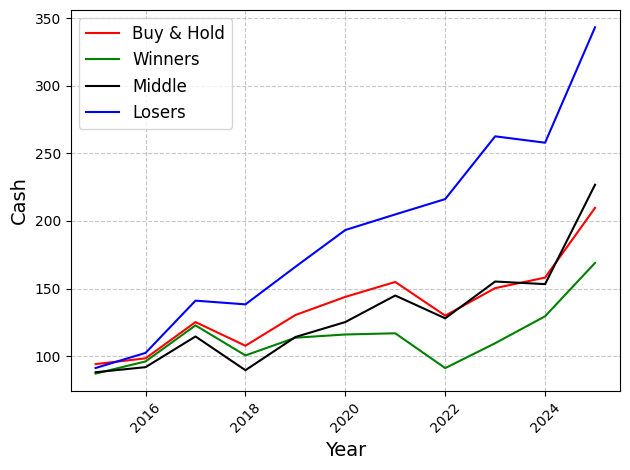

In [12]:
# Quarterly Growth Curve
import matplotlib.pyplot as plt

years = range(2015, 2026)
plt.plot(years, df7['Value'], label='Buy & Hold', color='RED')
plt.plot(years, df4['Winners'], label='Winners',color="GREEN")
plt.plot(years, df4['Median'], label='Middle', color="BLACK")
plt.plot(years, df4['Losers'], label='Losers', color="BLUE") 

#plt.title('Cash Values Over Years', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Cash', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

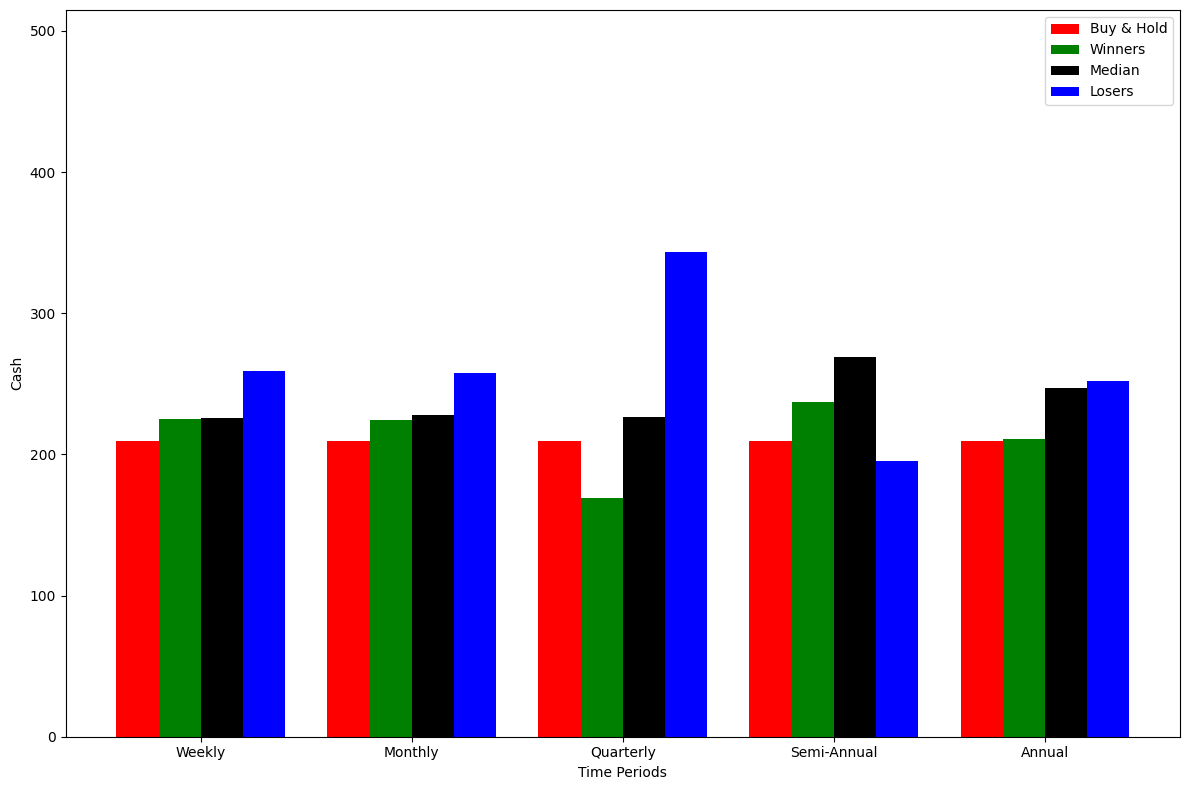

In [13]:
import matplotlib.pyplot as plt
import numpy as np


bh_values = [df7["Value"].iloc[-1],df7["Value"].iloc[-1],df7["Value"].iloc[-1],df7["Value"].iloc[-1],df7["Value"].iloc[-1]]
w_values = [df6["Winners"].iloc[-1],df5["Winners"].iloc[-1],df4["Winners"].iloc[-1],df3["Winners"].iloc[-1],df2["Winners"].iloc[-1]]
l_values = [df6["Losers"].iloc[-1],df5["Losers"].iloc[-1],df4["Losers"].iloc[-1],df3["Losers"].iloc[-1],df2["Losers"].iloc[-1]]
m_values = [df6["Median"].iloc[-1],df5["Median"].iloc[-1],df4["Median"].iloc[-1],df3["Median"].iloc[-1],df2["Median"].iloc[-1]]

categories = ["Weekly", 'Monthly','Quarterly', 'Semi-Annual', 'Annual']
labels = ['Buy & Hold', 'Winners', 'Median', 'Losers']

n_categories = len(categories)

x = np.arange(n_categories)

width = 0.2

plt.figure(figsize=(12, 8))

bars_bh = plt.bar(x - 1.5*width, bh_values, width, label='Buy & Hold', color='red')
bars_w = plt.bar(x - 0.5*width, w_values, width, label='Winners', color='green')
bars_m = plt.bar(x + 0.5*width, m_values, width, label='Median', color='black')
bars_l = plt.bar(x + 1.5*width, l_values, width, label='Losers', color='blue')


plt.xlabel('Time Periods')
plt.ylabel('Cash')
#plt.title('Cash Values by Category and Time Period')
plt.xticks(x, categories)
plt.legend()

def add_value_labels(bars):
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', ha='center', va='bottom')

max_value = max(max(bh_values), max(w_values), max(l_values), max(m_values))
plt.ylim(0, max_value * 1.5) 

plt.tight_layout()
plt.show()


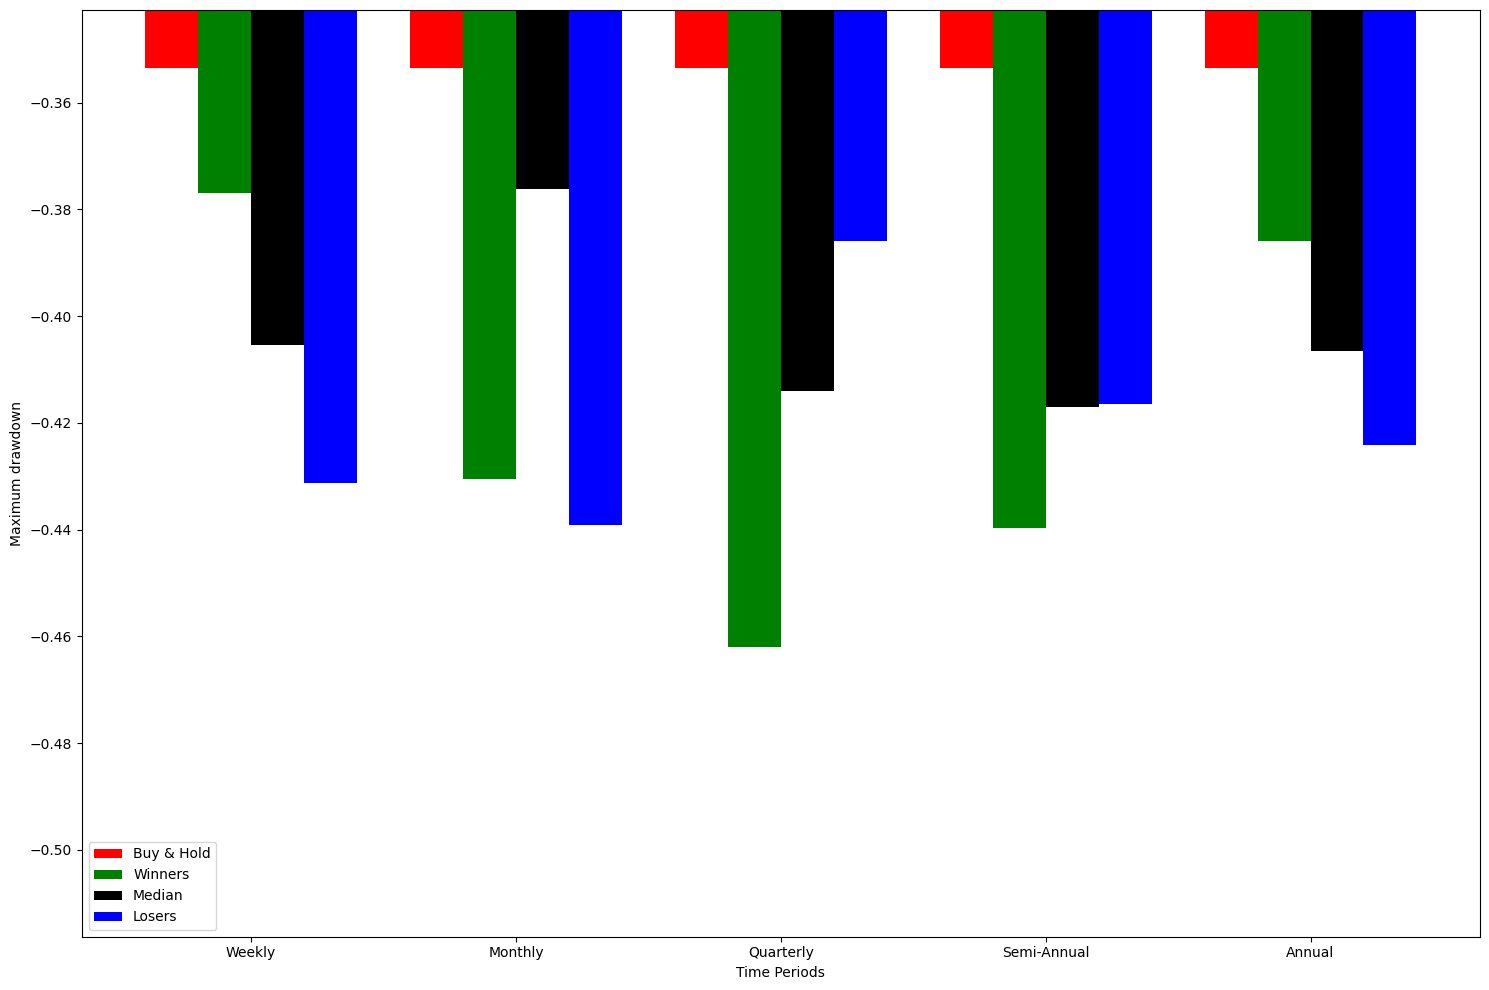

In [14]:
import matplotlib.pyplot as plt
import numpy as np

bh_values = [bh_week_maxdd,bh_mon_maxdd,bh_quar_maxdd,bh_sa_maxdd,bh_a_maxdd]
w_values = [w_week_maxdd,w_mon_maxdd,w_quar_maxdd,w_sa_maxdd,w_a_maxdd]
l_values = [l_week_maxdd,l_mon_maxdd,l_quar_maxdd,l_sa_maxdd,l_a_maxdd]
m_values = [m_week_maxdd,m_mon_maxdd,m_quar_maxdd,m_sa_maxdd,m_a_maxdd]

categories = ["Weekly",'Monthly','Quarterly', 'Semi-Annual', 'Annual']
labels = ['Buy & Hold', 'Winners', 'Median', 'Losers']


n_categories = len(categories)

x = np.arange(n_categories)

width = 0.2

plt.figure(figsize=(15, 10))

bars_bh = plt.bar(x - 1.5*width, bh_values, width, label='Buy & Hold', color='red')
bars_w = plt.bar(x - 0.5*width, w_values, width, label='Winners', color='green')
bars_m = plt.bar(x + 0.5*width, m_values, width, label='Median', color='black')
bars_l = plt.bar(x + 1.5*width, l_values, width, label='Losers', color='blue')



plt.xlabel('Time Periods')
plt.ylabel('Maximum drawdown')
#plt.title('Cash Values by Category and Time Period')
plt.xticks(x, categories)
plt.legend()


# Adjust y-scale to increase negative direction
y_min = min(min(bh_values), min(w_values), min(l_values), min(m_values))
y_max = max(max(bh_values), max(w_values), max(l_values), max(m_values))
y_range = y_max - y_min

# Extend the lower limit further into the negative
plt.ylim(y_min - 0.5 * y_range, y_max + 0.1 * y_range)



def add_value_labels(bars):
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', ha='center', va='top')

plt.tight_layout()
plt.show()

In [15]:
w_values

[-0.37697752343732993,
 -0.4305605212197837,
 -0.4620092877440458,
 -0.4397225036800015,
 -0.38596949279189574]

In [16]:
m_values

[-0.4053839569728671,
 -0.3761993813986173,
 -0.4140118562347089,
 -0.4170330453381509,
 -0.40645026142460833]

In [17]:
l_values

[-0.43121643382689645,
 -0.43920494325142134,
 -0.38594137547865764,
 -0.4165503011783258,
 -0.4241836556186495]

In [18]:
#ACWX buy and hold
import pandas as pd
import numpy as np
from empyrical import max_drawdown
import matplotlib.pyplot as plt

def yearly_returns(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True) 
    returns = {}
    for year in range(2014, 2026): 
        start_date = f"{year-1}-12-31"
        end_date = f"{year}-12-31"
        start_price = df['Adj Close'].loc[:start_date].iloc[-1]
        end_price = df['Adj Close'].loc[:end_date].iloc[-1]
        yearly_return = (end_price - start_price) / start_price
        returns[year] = yearly_return
    return pd.Series(returns)

data = {
    'fsggx': pd.read_csv("fsggx_weekly_return_detailed.csv")
}

yearly_returns_dict = {key: yearly_returns(df) for key, df in data.items()}
final_df = pd.DataFrame(yearly_returns_dict)
final_df.index.name = 'Date'

cash_annual_bh = []
cash_bh = 100
for year in range(2015, 2026):
    total_returns_bh = cash_bh * (1 + final_df.loc[year])
    cash_bh=total_returns_bh
    cash_annual_bh.append((year, total_returns_bh))

years_w, cash_values_bh = zip(*cash_annual_bh)
data=cash_annual_bh
years = [item[0] for item in data]
values = [item[1]['fsggx'] for item in data]

df1 = pd.DataFrame({'Year': years, 'Value': values})
initial_value = 100
df1['Annualized_Return'] = (df1['Value'] - df1['Value'].shift(1, fill_value=initial_value)) / df1['Value'].shift(1, fill_value=initial_value)*100


df=pd.read_csv("fsggx_weekly_return_detailed.csv")
df=df[df["Year"]>=2015]

yearly_volatility = df.groupby('Year')['Return'].std() * np.sqrt(252)

df1 = df1.merge(yearly_volatility.rename('Yearly_Volatility'), on='Year', how='left')

df1["Sharpe_Ratio"]=df1["Annualized_Return"]/df1["Yearly_Volatility"]
df1.set_index("Year",inplace=True)
df["Return"]=df["Return"]/100
yearly_max_drawdown = df.groupby("Year")["Return"].apply(lambda x: max_drawdown(x))
df1["Max_drawdown"]=yearly_max_drawdown*100
bh_a_maxdd = bh_sa_maxdd=bh_quar_maxdd=bh_mon_maxdd=bh_week_maxdd=max_drawdown(df["Return"])
print(bh_a_maxdd)
df7=pd.DataFrame()
df7=df1
df7


-0.34760184535999833


,Value,Annualized_Return,Yearly_Volatility,Sharpe_Ratio,Max_drawdown
Year,,,,,
2015,94.357893,-5.642107,15.120324,-0.373147,-18.699638
2016,98.734491,4.638296,16.874202,0.274875,-11.863762
2017,126.094043,27.710227,7.222620,3.836590,-2.300130
2018,108.530544,-13.928888,13.959754,-0.997789,-22.245246
2019,131.717881,21.364803,10.558300,2.023508,-8.045523
2020,145.851095,10.729912,29.048925,0.369374,-34.117316
2021,157.138254,7.738824,12.736150,0.607627,-7.022475
2022,132.383485,-15.753496,20.641731,-0.763187,-28.583132
2023,153.001821,15.574704,12.433486,1.252642,-11.682400


In [19]:
#ACWX buy and hold
import pandas as pd
import numpy as np
from empyrical import max_drawdown
import matplotlib.pyplot as plt

def yearly_returns(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True) 
    returns = {}
    for year in range(2014, 2026): 
        start_date = f"{year-1}-12-31"
        end_date = f"{year}-12-31"
        start_price = df['Adj Close'].loc[:start_date].iloc[-1]
        end_price = df['Adj Close'].loc[:end_date].iloc[-1]
        yearly_return = (end_price - start_price) / start_price
        returns[year] = yearly_return
    return pd.Series(returns)

data = {
    'igifx': pd.read_csv("igifx_weekly_return_detailed.csv")
}

yearly_returns_dict = {key: yearly_returns(df) for key, df in data.items()}
final_df = pd.DataFrame(yearly_returns_dict)
final_df.index.name = 'Date'

cash_annual_bh = []
cash_bh = 100
for year in range(2015, 2026):
    total_returns_bh = cash_bh * (1 + final_df.loc[year])
    cash_bh=total_returns_bh
    cash_annual_bh.append((year, total_returns_bh))

years_w, cash_values_bh = zip(*cash_annual_bh)
data=cash_annual_bh
years = [item[0] for item in data]
values = [item[1]['igifx'] for item in data]

df1 = pd.DataFrame({'Year': years, 'Value': values})
initial_value = 100
df1['Annualized_Return'] = (df1['Value'] - df1['Value'].shift(1, fill_value=initial_value)) / df1['Value'].shift(1, fill_value=initial_value)*100


df=pd.read_csv("igifx_weekly_return_detailed.csv")
df=df[df["Year"]>=2015]

yearly_volatility = df.groupby('Year')['Return'].std() * np.sqrt(252)

df1 = df1.merge(yearly_volatility.rename('Yearly_Volatility'), on='Year', how='left')

df1["Sharpe_Ratio"]=df1["Annualized_Return"]/df1["Yearly_Volatility"]
df1.set_index("Year",inplace=True)
df["Return"]=df["Return"]/100
yearly_max_drawdown = df.groupby("Year")["Return"].apply(lambda x: max_drawdown(x))
df1["Max_drawdown"]=yearly_max_drawdown*100
bh_a_maxdd = bh_sa_maxdd=bh_quar_maxdd=bh_mon_maxdd=bh_week_maxdd=max_drawdown(df["Return"])
print(bh_a_maxdd)
df7=pd.DataFrame()
df7=df1
df7


-0.3578957204374717


,Value,Annualized_Return,Yearly_Volatility,Sharpe_Ratio,Max_drawdown
Year,,,,,
2015,91.722050,-8.277950,14.796563,-0.559451,-16.621397
2016,93.669441,2.123143,15.875895,0.133734,-10.834274
2017,118.056224,26.034941,6.797862,3.829872,-2.046543
2018,101.016397,-14.433654,13.473064,-1.071297,-22.468610
2019,128.385609,27.093830,10.831686,2.501349,-6.583178
2020,138.377538,7.782749,29.981213,0.259588,-35.789572
2021,159.218935,15.061257,14.159741,1.063668,-7.980528
2022,136.154230,-14.486157,20.059677,-0.722153,-29.070969
2023,156.876148,15.219445,11.879173,1.281187,-10.703309


In [20]:
#ACWX buy and hold
import pandas as pd
import numpy as np
from empyrical import max_drawdown
import matplotlib.pyplot as plt

def yearly_returns(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True) 
    returns = {}
    for year in range(2014, 2026): 
        start_date = f"{year-1}-12-31"
        end_date = f"{year}-12-31"
        start_price = df['Adj Close'].loc[:start_date].iloc[-1]
        end_price = df['Adj Close'].loc[:end_date].iloc[-1]
        yearly_return = (end_price - start_price) / start_price
        returns[year] = yearly_return
    return pd.Series(returns)

data = {
    'lmeax': pd.read_csv("lmeax_weekly_return_detailed.csv")
}

yearly_returns_dict = {key: yearly_returns(df) for key, df in data.items()}
final_df = pd.DataFrame(yearly_returns_dict)
final_df.index.name = 'Date'

cash_annual_bh = []
cash_bh = 100
for year in range(2015, 2026):
    total_returns_bh = cash_bh * (1 + final_df.loc[year])
    cash_bh=total_returns_bh
    cash_annual_bh.append((year, total_returns_bh))

years_w, cash_values_bh = zip(*cash_annual_bh)
data=cash_annual_bh
years = [item[0] for item in data]
values = [item[1]['lmeax'] for item in data]

df1 = pd.DataFrame({'Year': years, 'Value': values})
initial_value = 100
df1['Annualized_Return'] = (df1['Value'] - df1['Value'].shift(1, fill_value=initial_value)) / df1['Value'].shift(1, fill_value=initial_value)*100


df=pd.read_csv("lmeax_weekly_return_detailed.csv")
df=df[df["Year"]>=2015]

yearly_volatility = df.groupby('Year')['Return'].std() * np.sqrt(252)

df1 = df1.merge(yearly_volatility.rename('Yearly_Volatility'), on='Year', how='left')

df1["Sharpe_Ratio"]=df1["Annualized_Return"]/df1["Yearly_Volatility"]
df1.set_index("Year",inplace=True)
df["Return"]=df["Return"]/100
yearly_max_drawdown = df.groupby("Year")["Return"].apply(lambda x: max_drawdown(x))
df1["Max_drawdown"]=yearly_max_drawdown*100
bh_a_maxdd = bh_sa_maxdd=bh_quar_maxdd=bh_mon_maxdd=bh_week_maxdd=max_drawdown(df["Return"])
print(bh_a_maxdd)
df7=pd.DataFrame()
df7=df1
df7


-0.3855037641849196


,Value,Annualized_Return,Yearly_Volatility,Sharpe_Ratio,Max_drawdown
Year,,,,,
2015,101.855511,1.855511,15.600124,0.118942,-15.072813
2016,102.375465,0.510482,17.333233,0.029451,-13.141949
2017,127.474617,24.516765,7.425773,3.301578,-2.497174
2018,107.042906,-16.028063,12.833799,-1.248895,-23.726060
2019,127.410452,19.027460,10.391561,1.831049,-8.494679
2020,131.831243,3.469724,28.294981,0.122627,-34.748256
2021,156.882623,19.002612,13.031130,1.458247,-5.980327
2022,136.827018,-12.783828,21.262008,-0.601252,-28.572787
2023,163.627780,19.587332,12.483632,1.569041,-9.583815


In [21]:
#ACWX buy and hold
import pandas as pd
import numpy as np
from empyrical import max_drawdown
import matplotlib.pyplot as plt

def yearly_returns(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True) 
    returns = {}
    for year in range(2014, 2026): 
        start_date = f"{year-1}-12-31"
        end_date = f"{year}-12-31"
        start_price = df['Adj Close'].loc[:start_date].iloc[-1]
        end_price = df['Adj Close'].loc[:end_date].iloc[-1]
        yearly_return = (end_price - start_price) / start_price
        returns[year] = yearly_return
    return pd.Series(returns)

data = {
    'spy': pd.read_csv("spy_weekly_return_detailed.csv")
}

yearly_returns_dict = {key: yearly_returns(df) for key, df in data.items()}
final_df = pd.DataFrame(yearly_returns_dict)
final_df.index.name = 'Date'

cash_annual_bh = []
cash_bh = 100
for year in range(2015, 2026):
    total_returns_bh = cash_bh * (1 + final_df.loc[year])
    cash_bh=total_returns_bh
    cash_annual_bh.append((year, total_returns_bh))

years_w, cash_values_bh = zip(*cash_annual_bh)
data=cash_annual_bh
years = [item[0] for item in data]
values = [item[1]['spy'] for item in data]

df1 = pd.DataFrame({'Year': years, 'Value': values})
initial_value = 100
df1['Annualized_Return'] = (df1['Value'] - df1['Value'].shift(1, fill_value=initial_value)) / df1['Value'].shift(1, fill_value=initial_value)*100


df=pd.read_csv("spy_weekly_return_detailed.csv")
df=df[df["Year"]>=2015]

yearly_volatility = df.groupby('Year')['Return'].std() * np.sqrt(252)

df1 = df1.merge(yearly_volatility.rename('Yearly_Volatility'), on='Year', how='left')

df1["Sharpe_Ratio"]=df1["Annualized_Return"]/df1["Yearly_Volatility"]
df1.set_index("Year",inplace=True)
df["Return"]=df["Return"]/100
yearly_max_drawdown = df.groupby("Year")["Return"].apply(lambda x: max_drawdown(x))
df1["Max_drawdown"]=yearly_max_drawdown*100
bh_a_maxdd = bh_sa_maxdd=bh_quar_maxdd=bh_mon_maxdd=bh_week_maxdd=max_drawdown(df["Return"])
print(bh_a_maxdd)
df7=pd.DataFrame()
df7=df1
df7


-0.33716432880954617


,Value,Annualized_Return,Yearly_Volatility,Sharpe_Ratio,Max_drawdown
Year,,,,,
2015,101.234294,1.234294,15.431508,0.079985,-11.908937
2016,113.380279,11.997895,13.061735,0.918553,-10.304041
2017,137.989920,21.705399,6.743939,3.218505,-2.614278
2018,131.685182,-4.568985,17.036870,-0.268182,-19.348382
2019,172.802350,31.223838,12.511095,2.495692,-6.618770
2020,204.479844,18.331634,33.397973,0.548885,-33.716433
2021,263.224393,28.728772,12.988880,2.211797,-5.114799
2022,215.382398,-18.175365,24.242918,-0.749719,-24.494036
2023,271.760453,26.175795,13.075651,2.001873,-9.974162


In [22]:
#ACWX buy and hold
import pandas as pd
import numpy as np
from empyrical import max_drawdown
import matplotlib.pyplot as plt

def yearly_returns(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True) 
    returns = {}
    for year in range(2014, 2026): 
        start_date = f"{year-1}-12-31"
        end_date = f"{year}-12-31"
        start_price = df['Adj Close'].loc[:start_date].iloc[-1]
        end_price = df['Adj Close'].loc[:end_date].iloc[-1]
        yearly_return = (end_price - start_price) / start_price
        returns[year] = yearly_return
    return pd.Series(returns)

data = {
    'acwi': pd.read_csv("acwi_weekly_return_detailed.csv")
}

yearly_returns_dict = {key: yearly_returns(df) for key, df in data.items()}
final_df = pd.DataFrame(yearly_returns_dict)
final_df.index.name = 'Date'

cash_annual_bh = []
cash_bh = 100
for year in range(2015, 2026):
    total_returns_bh = cash_bh * (1 + final_df.loc[year])
    cash_bh=total_returns_bh
    cash_annual_bh.append((year, total_returns_bh))

years_w, cash_values_bh = zip(*cash_annual_bh)
data=cash_annual_bh
years = [item[0] for item in data]
values = [item[1]['acwi'] for item in data]

df1 = pd.DataFrame({'Year': years, 'Value': values})
initial_value = 100
df1['Annualized_Return'] = (df1['Value'] - df1['Value'].shift(1, fill_value=initial_value)) / df1['Value'].shift(1, fill_value=initial_value)*100


df=pd.read_csv("acwi_weekly_return_detailed.csv")
df=df[df["Year"]>=2015]

yearly_volatility = df.groupby('Year')['Return'].std() * np.sqrt(252)

df1 = df1.merge(yearly_volatility.rename('Yearly_Volatility'), on='Year', how='left')

df1["Sharpe_Ratio"]=df1["Annualized_Return"]/df1["Yearly_Volatility"]
df1.set_index("Year",inplace=True)
df["Return"]=df["Return"]/100
yearly_max_drawdown = df.groupby("Year")["Return"].apply(lambda x: max_drawdown(x))
df1["Max_drawdown"]=yearly_max_drawdown*100
bh_a_maxdd = bh_sa_maxdd=bh_quar_maxdd=bh_mon_maxdd=bh_week_maxdd=max_drawdown(df["Return"])
print(bh_a_maxdd)
df7=pd.DataFrame()
df7=df1
df7


-0.335248597329585


,Value,Annualized_Return,Yearly_Volatility,Sharpe_Ratio,Max_drawdown
Year,,,,,
2015,97.790986,-2.209014,15.635617,-0.141281,-15.142191
2016,106.002157,8.396654,14.959440,0.561295,-11.286921
2017,131.796030,24.333347,6.668063,3.649238,-1.937895
2018,119.769774,-9.124900,15.518859,-0.587988,-19.493714
2019,151.616187,26.589691,11.792193,2.254855,-6.527883
2020,176.385306,16.336724,32.062459,0.509528,-33.524860
2021,209.301853,18.661729,12.542779,1.487846,-5.479512
2022,170.820578,-18.385540,22.739308,-0.808536,-26.422106
2023,208.869816,22.274388,12.576348,1.771133,-10.864101


In [23]:
#ACWX buy and hold
import pandas as pd
import numpy as np
from empyrical import max_drawdown
import matplotlib.pyplot as plt

def yearly_returns(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True) 
    returns = {}
    for year in range(2014, 2026): 
        start_date = f"{year-1}-12-31"
        end_date = f"{year}-12-31"
        start_price = df['Adj Close'].loc[:start_date].iloc[-1]
        end_price = df['Adj Close'].loc[:end_date].iloc[-1]
        yearly_return = (end_price - start_price) / start_price
        returns[year] = yearly_return
    return pd.Series(returns)

data = {
    'acwx': pd.read_csv("acwx_weekly_return_detailed.csv")
}

yearly_returns_dict = {key: yearly_returns(df) for key, df in data.items()}
final_df = pd.DataFrame(yearly_returns_dict)
final_df.index.name = 'Date'

cash_annual_bh = []
cash_bh = 100
for year in range(2015, 2026):
    total_returns_bh = cash_bh * (1 + final_df.loc[year])
    cash_bh=total_returns_bh
    cash_annual_bh.append((year, total_returns_bh))

years_w, cash_values_bh = zip(*cash_annual_bh)
data=cash_annual_bh
years = [item[0] for item in data]
values = [item[1]['acwx'] for item in data]

df1 = pd.DataFrame({'Year': years, 'Value': values})
initial_value = 100
df1['Annualized_Return'] = (df1['Value'] - df1['Value'].shift(1, fill_value=initial_value)) / df1['Value'].shift(1, fill_value=initial_value)*100


df=pd.read_csv("acwx_weekly_return_detailed.csv")
df=df[df["Year"]>=2015]

yearly_volatility = df.groupby('Year')['Return'].std() * np.sqrt(252)

df1 = df1.merge(yearly_volatility.rename('Yearly_Volatility'), on='Year', how='left')

df1["Sharpe_Ratio"]=df1["Annualized_Return"]/df1["Yearly_Volatility"]
df1.set_index("Year",inplace=True)
df["Return"]=df["Return"]/100
yearly_max_drawdown = df.groupby("Year")["Return"].apply(lambda x: max_drawdown(x))
df1["Max_drawdown"]=yearly_max_drawdown*100
bh_a_maxdd = bh_sa_maxdd=bh_quar_maxdd=bh_mon_maxdd=bh_week_maxdd=max_drawdown(df["Return"])
print(bh_a_maxdd)
df7=pd.DataFrame()
df7=df1
df7


-0.35348979059921626


,Value,Annualized_Return,Yearly_Volatility,Sharpe_Ratio,Max_drawdown
Year,,,,,
2015,94.196872,-5.803128,16.874067,-0.343908,-18.730375
2016,98.473690,4.540297,18.264690,0.248583,-11.968217
2017,125.259296,27.200774,7.984955,3.406503,-2.356098
2018,107.788080,-13.948040,15.124893,-0.922191,-22.479039
2019,130.479365,21.051757,11.678296,1.802639,-8.234950
2020,143.903233,10.288116,31.546098,0.326130,-34.397471
2021,154.939418,7.669171,13.440178,0.570615,-7.281950
2022,130.042577,-16.068759,21.808541,-0.736810,-28.791233
2023,150.370296,15.631588,13.504605,1.157501,-12.062025


In [24]:
#ACWX buy and hold
import pandas as pd
import numpy as np
from empyrical import max_drawdown
import matplotlib.pyplot as plt

df=pd.read_excel("acwinew.xlsx")
df["Date"]=pd.to_datetime(df["Date"])
df["Year"]=df["Date"].dt.year
df=df[df["Year"]>=2015]
yearly_max_drawdown = df.groupby("Year")["Daily Returns"].apply(lambda x: max_drawdown(x)).reset_index().rename(columns={'Daily Returns': 'Annual MDD'})
yearly_max_drawdown["Annual MDD"]=yearly_max_drawdown["Annual MDD"]*100
print(yearly_max_drawdown)
yearly_max_drawdown.to_csv("acwinewmdd.csv")
bh_a_maxdd = bh_sa_maxdd=bh_quar_maxdd=bh_mon_maxdd=bh_week_maxdd=max_drawdown(df["Daily Returns"])
print(bh_a_maxdd)
df7=pd.DataFrame()
df7=df
df7


    Year  Annual MDD
0   2015  -18.752172
1   2016  -11.940888
2   2017   -2.195484
3   2018  -21.252028
4   2019   -7.861573
5   2020  -34.364112
6   2021   -6.990959
7   2022  -28.065365
8   2023  -11.519631
9   2024   -9.290103
10  2025  -13.125410
-0.3439285378412062


,Date,Price,Daily Returns,Total Returns,Total Capital,Year
1,2015-01-01,499.861,0.000004,0.000004,100.000400,2015
2,2015-01-02,497.020,-0.005684,-0.005680,99.432040,2015
3,2015-01-05,487.145,-0.019868,-0.025435,97.456483,2015
4,2015-01-06,482.016,-0.010529,-0.035696,96.430393,2015
5,2015-01-07,480.807,-0.002508,-0.038115,96.188525,2015
...,...,...,...,...,...,...
2866,2025-12-25,1114.236,0.000158,1.229101,222.910061,2025
2867,2025-12-26,1115.422,0.001064,1.231473,223.147328,2025
2868,2025-12-29,1116.436,0.000909,1.233502,223.350185,2025
2869,2025-12-30,1117.780,0.001204,1.236191,223.619061,2025


In [25]:
#ACWX buy and hold
import pandas as pd
import numpy as np
from empyrical import max_drawdown
import matplotlib.pyplot as plt

df=pd.read_excel("spnew.xlsx")
df["Date"]=pd.to_datetime(df["Date"])
df["Year"]=df["Date"].dt.year
df=df[df["Year"]>=2015]
yearly_max_drawdown = df.groupby("Year")["Daily Returns"].apply(lambda x: max_drawdown(x)).reset_index().rename(columns={'Daily Returns': 'Annual MDD'})
yearly_max_drawdown["Annual MDD"]=yearly_max_drawdown["Annual MDD"]*100
print(yearly_max_drawdown)
yearly_max_drawdown.to_csv("spnewmdd.csv")
bh_a_maxdd = bh_sa_maxdd=bh_quar_maxdd=bh_mon_maxdd=bh_week_maxdd=max_drawdown(df["Daily Returns"])
print(bh_a_maxdd)
df7=pd.DataFrame()
df7=df
df7


    Year  Annual MDD
0   2015  -12.036503
1   2016  -10.273446
2   2017   -2.581962
3   2018  -19.363490
4   2019   -6.620803
5   2020  -33.790462
6   2021   -5.122091
7   2022  -24.491638
8   2023   -9.940740
9   2024   -8.448339
10  2025  -18.747118
-0.33790461586269854


,Date,Price,Daily Returns,Total Returns,Portfolio Value,Year
1,2015-01-01,3769.44,0.000000,0.000000,99.000000,2015
2,2015-01-02,3768.68,-0.000202,-0.000202,98.979838,2015
3,2015-01-05,3700.03,-0.018216,-0.018414,97.158612,2015
4,2015-01-06,3667.14,-0.008889,-0.027139,96.286069,2015
5,2015-01-07,3710.94,0.011944,-0.015520,97.448045,2015
...,...,...,...,...,...,...
2866,2025-12-25,15409.70,0.000000,3.088061,407.806083,2025
2867,2025-12-26,15406.48,-0.000209,3.087207,407.720659,2025
2868,2025-12-29,15353.16,-0.003461,3.073061,406.306125,2025
2869,2025-12-30,15332.07,-0.001374,3.067466,405.746625,2025


In [26]:
w_values

[-0.37697752343732993,
 -0.4305605212197837,
 -0.4620092877440458,
 -0.4397225036800015,
 -0.38596949279189574]

In [27]:
m_values

[-0.4053839569728671,
 -0.3761993813986173,
 -0.4140118562347089,
 -0.4170330453381509,
 -0.40645026142460833]

In [28]:
l_values

[-0.43121643382689645,
 -0.43920494325142134,
 -0.38594137547865764,
 -0.4165503011783258,
 -0.4241836556186495]

In [29]:
#one last time

In [30]:
import pandas as pd
import numpy as np
from empyrical import max_drawdown
import matplotlib.pyplot as plt

df=pd.read_excel("MSCIACWI.xlsx")
df["Date"]=pd.to_datetime(df["Date"])
df["Year"]=df["Date"].dt.year
df=df[df["Year"]>=2015]
print(df.head(5))
yearly_max_drawdown = df.groupby("Year")["Daily Returns"].apply(lambda x: max_drawdown(x)).reset_index().rename(columns={'Daily Returns': 'Annual MDD'})
yearly_max_drawdown["Annual MDD"]=yearly_max_drawdown["Annual MDD"]*100
print(yearly_max_drawdown)
yearly_max_drawdown.to_csv("msciacwi.csv")
bh_a_maxdd = bh_sa_maxdd=bh_quar_maxdd=bh_mon_maxdd=bh_week_maxdd=max_drawdown(df["Daily Returns"])
print(bh_a_maxdd)
df7=pd.DataFrame()
df7=df
df7

        Date  Unnamed: 1  Total Capital  Total Returns  Daily Returns  \
1 2015-01-01     499.861     100.000400       0.000004       0.000004   
2 2015-01-02     497.020      99.432040      -0.005680      -0.005684   
3 2015-01-05     487.145      97.456483      -0.025435      -0.019868   
4 2015-01-06     482.016      96.430393      -0.035696      -0.010529   
5 2015-01-07     480.807      96.188525      -0.038115      -0.002508   

   Annualized Returns  Annualized St Dev  Modified Sharpe Ratio  \
1                 NaN                NaN                    NaN   
2                 NaN                NaN                    NaN   
3                 NaN                NaN                    NaN   
4                 NaN                NaN                    NaN   
5                 NaN                NaN                    NaN   

   Maximum Drawdown  Year  
1               NaN  2015  
2               NaN  2015  
3               NaN  2015  
4               NaN  2015  
5               Na

,Date,Unnamed: 1,Total Capital,Total Returns,Daily Returns,Annualized Returns,Annualized St Dev,Modified Sharpe Ratio,Maximum Drawdown,Year
1,2015-01-01,499.861,100.000400,0.000004,0.000004,NaN,NaN,NaN,NaN,2015
2,2015-01-02,497.020,99.432040,-0.005680,-0.005684,NaN,NaN,NaN,NaN,2015
3,2015-01-05,487.145,97.456483,-0.025435,-0.019868,NaN,NaN,NaN,NaN,2015
4,2015-01-06,482.016,96.430393,-0.035696,-0.010529,NaN,NaN,NaN,NaN,2015
5,2015-01-07,480.807,96.188525,-0.038115,-0.002508,NaN,NaN,NaN,NaN,2015
...,...,...,...,...,...,...,...,...,...,...
3128,2025-12-25,1114.236,222.910061,1.229101,0.000158,NaN,NaN,NaN,NaN,2025
3129,2025-12-26,1115.422,223.147328,1.231473,0.001064,NaN,NaN,NaN,NaN,2025
3130,2025-12-29,1116.436,223.350185,1.233502,0.000909,NaN,NaN,NaN,NaN,2025
3131,2025-12-30,1117.780,223.619061,1.236191,0.001204,NaN,NaN,NaN,NaN,2025


In [31]:
import pandas as pd
import numpy as np
from empyrical import max_drawdown
import matplotlib.pyplot as plt

df=pd.read_excel("LMEAX.xlsx")
df["Date"]=pd.to_datetime(df["Date"])
df["Year"]=df["Date"].dt.year
df=df[df["Year"]>=2015]
print(df.head(5))
yearly_max_drawdown = df.groupby("Year")["Daily Returns"].apply(lambda x: max_drawdown(x)).reset_index().rename(columns={'Daily Returns': 'Annual MDD'})
yearly_max_drawdown["Annual MDD"]=yearly_max_drawdown["Annual MDD"]*100
print(yearly_max_drawdown)
yearly_max_drawdown.to_csv("lmeax.csv")
bh_a_maxdd = bh_sa_maxdd=bh_quar_maxdd=bh_mon_maxdd=bh_week_maxdd=max_drawdown(df["Daily Returns"])
print(bh_a_maxdd)
df7=pd.DataFrame()
df7=df
df7

        Date  Unnamed: 1  Daily Returns Unnamed: 3     Date.1  \
1 2015-01-02      168.11      -0.002906  99.709371 2015-01-02   
2 2015-01-05      165.20      -0.017310  97.983393 2015-01-05   
3 2015-01-06      163.37      -0.011077  96.897983 2015-01-06   
4 2015-01-07      164.47       0.006733  97.550415 2015-01-07   
5 2015-01-08      167.02       0.015504  99.062871 2015-01-08   

   Date Difference   Open   High    Low  Close   Adj Close  Volume  \
1              0.0  13.83  13.83  13.83   13.83        7.72      -   
2              0.0  13.59  13.59  13.59   13.59        7.58      -   
3              0.0  13.44  13.44  13.44   13.44        7.50      -   
4              0.0  13.53  13.53  13.53   13.53        7.55      -   
5              0.0  13.74  13.74  13.74   13.74        7.67      -   

   Unnamed: 12  Total Returns Portfolio Value    Year  
1    -0.002584      -0.425595       99.741602  2015.0  
2    -0.018135      -0.436012       97.932817  2015.0  
3    -0.010554      

,Date,Unnamed: 1,Daily Returns,Unnamed: 3,Date.1,Date Difference,Open,High,Low,Close,Adj Close,Volume,Unnamed: 12,Total Returns,Portfolio Value,Year
1,2015-01-02,168.11,-0.002906,99.709371,2015-01-02,0.0,13.83,13.83,13.83,13.83,7.72,-,-0.002584,-0.425595,99.741602,2015.0
2,2015-01-05,165.20,-0.017310,97.983393,2015-01-05,0.0,13.59,13.59,13.59,13.59,7.58,-,-0.018135,-0.436012,97.932817,2015.0
3,2015-01-06,163.37,-0.011077,96.897983,2015-01-06,0.0,13.44,13.44,13.44,13.44,7.50,-,-0.010554,-0.441964,96.899225,2015.0
4,2015-01-07,164.47,0.006733,97.550415,2015-01-07,0.0,13.53,13.53,13.53,13.53,7.55,-,0.006667,-0.438244,97.54522,2015.0
5,2015-01-08,167.02,0.015504,99.062871,2015-01-08,0.0,13.74,13.74,13.74,13.74,7.67,-,0.015894,-0.429315,99.095607,2015.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2762,2025-12-24,347.49,-0.000489,206.103203,2025-12-24,0.0,19.95,19.95,19.95,19.95,19.95,-,-0.000501,0.484375,257.751938,2025.0
2763,2025-12-26,347.84,0.001007,206.310795,2025-12-26,0.0,19.97,19.97,19.97,19.97,19.97,-,0.001003,0.485863,258.010336,2025.0
2764,2025-12-29,346.27,-0.004514,205.379597,2025-12-29,0.0,19.88,19.88,19.88,19.88,19.88,-,-0.004507,0.479167,256.847545,2025.0
2765,2025-12-30,346.97,0.002022,205.794781,2025-12-30,0.0,19.92,19.92,19.92,19.92,19.92,-,0.002012,0.482143,257.364341,2025.0


In [32]:
import pandas as pd
import numpy as np
from empyrical import max_drawdown
import matplotlib.pyplot as plt

df=pd.read_excel("SP500.xlsx")
df["Date"]=pd.to_datetime(df["Date"])
df["Year"]=df["Date"].dt.year
df=df[df["Year"]>=2015]
print(df.head(5))
yearly_max_drawdown = df.groupby("Year")["Daily Returns"].apply(lambda x: max_drawdown(x)).reset_index().rename(columns={'Daily Returns': 'Annual MDD'})
yearly_max_drawdown["Annual MDD"]=yearly_max_drawdown["Annual MDD"]*100
print(yearly_max_drawdown)
yearly_max_drawdown.to_csv("sp500.csv")
bh_a_maxdd = bh_sa_maxdd=bh_quar_maxdd=bh_mon_maxdd=bh_week_maxdd=max_drawdown(df["Daily Returns"])
print(bh_a_maxdd)
df7=pd.DataFrame()
df7=df
df7

        Date  Unnamed: 1  Unnamed: 2  Unnamed: 3  Unnamed: 4  Daily Returns  \
1 2015-01-01     3769.44    0.000000    0.000000   99.000000       0.000000   
2 2015-01-02     3768.68   -0.000202   -0.000202   98.979838      -0.000202   
3 2015-01-05     3700.03   -0.018216   -0.018414   97.158612      -0.018216   
4 2015-01-06     3667.14   -0.008889   -0.027139   96.286069      -0.008889   
5 2015-01-07     3710.94    0.011944   -0.015520   97.448045       0.011944   

   Year  
1  2015  
2  2015  
3  2015  
4  2015  
5  2015  
    Year  Annual MDD
0   2015  -12.036503
1   2016  -10.273446
2   2017   -2.581962
3   2018  -19.363490
4   2019   -6.620803
5   2020  -33.790462
6   2021   -5.122091
7   2022  -24.491638
8   2023   -9.940740
9   2024   -8.448339
10  2025  -18.747118
-0.33790461586269854


,Date,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Daily Returns,Year
1,2015-01-01,3769.44,0.000000,0.000000,99.000000,0.000000,2015
2,2015-01-02,3768.68,-0.000202,-0.000202,98.979838,-0.000202,2015
3,2015-01-05,3700.03,-0.018216,-0.018414,97.158612,-0.018216,2015
4,2015-01-06,3667.14,-0.008889,-0.027139,96.286069,-0.008889,2015
5,2015-01-07,3710.94,0.011944,-0.015520,97.448045,0.011944,2015
...,...,...,...,...,...,...,...
2866,2025-12-25,15409.70,0.000000,3.088061,407.806083,0.000000,2025
2867,2025-12-26,15406.48,-0.000209,3.087207,407.720659,-0.000209,2025
2868,2025-12-29,15353.16,-0.003461,3.073061,406.306125,-0.003461,2025
2869,2025-12-30,15332.07,-0.001374,3.067466,405.746625,-0.001374,2025


In [33]:
import pandas as pd
import numpy as np
from empyrical import max_drawdown
import matplotlib.pyplot as plt

df=pd.read_excel("FSGGX.xlsx")
df["Date"]=pd.to_datetime(df["Date"])
df["Year"]=df["Date"].dt.year
df=df[df["Year"]>=2015]
df["Daily Returns"]=df["Daily Returns"]/100
print(df.head(5))
yearly_max_drawdown = df.groupby("Year")["Daily Returns"].apply(lambda x: max_drawdown(x)).reset_index().rename(columns={'Daily Returns': 'Annual MDD'})
yearly_max_drawdown["Annual MDD"]=yearly_max_drawdown["Annual MDD"]*100
print(yearly_max_drawdown)
yearly_max_drawdown.to_csv("fsggx.csv")
bh_a_maxdd = bh_sa_maxdd=bh_quar_maxdd=bh_mon_maxdd=bh_week_maxdd=max_drawdown(df["Daily Returns"])
print(bh_a_maxdd)
df7=pd.DataFrame()
df7=df
df7

     Adj Close  Close   High    Low   Open  Volume  Daily Returns       Date  \
833   8.667212  11.47  11.47  11.47  11.47       0       -0.00520 2015-01-02   
834   8.485857  11.23  11.23  11.23  11.23       0       -0.02092 2015-01-05   
835   8.402736  11.12  11.12  11.12  11.12       0       -0.00980 2015-01-06   
836   8.478301  11.22  11.22  11.22  11.22       0        0.00899 2015-01-07   
837   8.614317  11.40  11.40  11.40  11.40       0        0.01604 2015-01-08   

     Week_Number  Year  Day    Weekday  mean_return  volatility  
833            0  2015    2     Friday       -0.520    0.000000  
834            1  2015    5     Monday       -0.219    1.479422  
835            1  2015    6    Tuesday       -0.219    1.479422  
836            1  2015    7  Wednesday       -0.219    1.479422  
837            1  2015    8   Thursday       -0.219    1.479422  
    Year  Annual MDD
0   2015  -18.699638
1   2016  -11.863762
2   2017   -2.300130
3   2018  -22.245246
4   2019   -8.0455

,Adj Close,Close,High,Low,Open,Volume,Daily Returns,Date,Week_Number,Year,Day,Weekday,mean_return,volatility
833,8.667212,11.470000,11.470000,11.470000,11.470000,0,-0.00520,2015-01-02,0,2015,2,Friday,-0.52000,0.000000
834,8.485857,11.230000,11.230000,11.230000,11.230000,0,-0.02092,2015-01-05,1,2015,5,Monday,-0.21900,1.479422
835,8.402736,11.120000,11.120000,11.120000,11.120000,0,-0.00980,2015-01-06,1,2015,6,Tuesday,-0.21900,1.479422
836,8.478301,11.220000,11.220000,11.220000,11.220000,0,0.00899,2015-01-07,1,2015,7,Wednesday,-0.21900,1.479422
837,8.614317,11.400000,11.400000,11.400000,11.400000,0,0.01604,2015-01-08,1,2015,8,Thursday,-0.21900,1.479422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3594,18.660000,18.660000,18.660000,18.660000,18.660000,0,0.00000,2025-12-24,51,2025,24,Wednesday,0.39175,0.319982
3595,18.709999,18.709999,18.709999,18.709999,18.709999,0,0.00268,2025-12-26,51,2025,26,Friday,0.39175,0.319982
3596,18.680000,18.680000,18.680000,18.680000,18.680000,0,-0.00160,2025-12-29,52,2025,29,Monday,-0.08900,0.171875
3597,18.700001,18.700001,18.700001,18.700001,18.700001,0,0.00107,2025-12-30,52,2025,30,Tuesday,-0.08900,0.171875


In [34]:
import pandas as pd
import numpy as np
from empyrical import max_drawdown
import matplotlib.pyplot as plt

df=pd.read_excel("IGIFX.xlsx")
df["Date"]=pd.to_datetime(df["Date"])
df["Year"]=df["Date"].dt.year
df=df[df["Year"]>=2015]
df["Daily Returns"]=df["Daily Returns"]/100
print(df.head(5))
yearly_max_drawdown = df.groupby("Year")["Daily Returns"].apply(lambda x: max_drawdown(x)).reset_index().rename(columns={'Daily Returns': 'Annual MDD'})
yearly_max_drawdown["Annual MDD"]=yearly_max_drawdown["Annual MDD"]*100
print(yearly_max_drawdown)
yearly_max_drawdown.to_csv("igifx.csv")
bh_a_maxdd = bh_sa_maxdd=bh_quar_maxdd=bh_mon_maxdd=bh_week_maxdd=max_drawdown(df["Daily Returns"])
print(bh_a_maxdd)
df7=pd.DataFrame()
df7=df
df7

      Adj Close      Close       High        Low       Open  Volume  \
1574  19.125067  31.770000  31.770000  31.770000  31.770000     0.0   
1575  18.745813  31.139999  31.139999  31.139999  31.139999     0.0   
1576  18.535116  30.790001  30.790001  30.790001  30.790001     0.0   
1577  18.673580  31.020000  31.020000  31.020000  31.020000     0.0   
1578  18.920391  31.430000  31.430000  31.430000  31.430000     0.0   

      Daily Returns       Date  Week_Number  Year  Day    Weekday  \
1574       -0.00157 2015-01-02          0.0  2015  2.0     Friday   
1575       -0.01983 2015-01-05          1.0  2015  5.0     Monday   
1576       -0.01124 2015-01-06          1.0  2015  6.0    Tuesday   
1577        0.00747 2015-01-07          1.0  2015  7.0  Wednesday   
1578        0.01322 2015-01-08          1.0  2015  8.0   Thursday   

      mean_return  volatility  
1574      -0.1570    0.000000  
1575      -0.3158    1.350499  
1576      -0.3158    1.350499  
1577      -0.3158    1.350499 

,Adj Close,Close,High,Low,Open,Volume,Daily Returns,Date,Week_Number,Year,Day,Weekday,mean_return,volatility
1574,19.125067,31.770000,31.770000,31.770000,31.770000,0.0,-0.001570,2015-01-02,0.0,2015,2.0,Friday,-0.15700,0.000000
1575,18.745813,31.139999,31.139999,31.139999,31.139999,0.0,-0.019830,2015-01-05,1.0,2015,5.0,Monday,-0.31580,1.350499
1576,18.535116,30.790001,30.790001,30.790001,30.790001,0.0,-0.011240,2015-01-06,1.0,2015,6.0,Tuesday,-0.31580,1.350499
1577,18.673580,31.020000,31.020000,31.020000,31.020000,0.0,0.007470,2015-01-07,1.0,2015,7.0,Wednesday,-0.31580,1.350499
1578,18.920391,31.430000,31.430000,31.430000,31.430000,0.0,0.013220,2015-01-08,1.0,2015,8.0,Thursday,-0.31580,1.350499
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4335,44.770000,44.770000,44.770000,44.770000,44.770000,0.0,-0.001120,2025-12-24,51.0,2025,24.0,Wednesday,0.29775,0.324291
4336,44.869999,44.869999,44.869999,44.869999,44.869999,0.0,0.002230,2025-12-26,51.0,2025,26.0,Friday,0.29775,0.324291
4337,44.820000,44.820000,44.820000,44.820000,44.820000,0.0,-0.001110,2025-12-29,52.0,2025,29.0,Monday,0.06700,0.251730
4338,44.930000,44.930000,44.930000,44.930000,44.930000,0.0,0.002450,2025-12-30,52.0,2025,30.0,Tuesday,0.06700,0.251730
